# Traffic-signal-control experiment

This notebook compares simple baselines, MAPPO, and reward-sharing MAPPO on a network.

In [1]:
import os
import subprocess
import sys
import sysconfig
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    ROOT = Path("/content/marl-tsc")

    if not ROOT.exists():
        subprocess.run([
            "git", "clone", "--branch", "zak-pre-experiment",
            "--single-branch", "https://github.com/abergh18/marl-tsc.git",
            str(ROOT)
        ], check=True)

    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "eclipse-sumo"
    ], check=True)

    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "-r", str(ROOT / "requirements.txt"),
    ], check=True)

    import sumo
    os.environ["SUMO_HOME"] = sumo.SUMO_HOME
    sys.path.insert(0, os.path.join(sumo.SUMO_HOME, "tools"))

    from google.colab import userdata

    #Get access token
    token = userdata.get('GH_TOKEN')

else:
    # Run VS Code from somewhere inside the marl-tsc repository.
    ROOT = next(
        folder
        for folder in (Path.cwd(), *Path.cwd().parents)
        if (folder / "src" / "marl_tsc").exists()
    )

# Make /src/marl_tsc importable.
sys.path.insert(0, str(ROOT / "src"))

# Relative project paths now work consistently.
os.chdir(ROOT)

print(f"Running in {'Colab' if IN_COLAB else 'VS Code'} from {ROOT}")

Running in Colab from /content/marl-tsc


In [2]:
if not IN_COLAB:
  %reload_ext autoreload
  %autoreload 2

import matplotlib.pyplot as plt

from marl_tsc.baselines import fixed_time_actions, random_actions
from marl_tsc.mappo import train_mappo
from marl_tsc.network_types import CityNetwork, GridNetwork
from marl_tsc.simulation_generator import SimulationGenerator
from marl_tsc.training import (
    evaluate_policies,
    export_policy_replay,
    evaluation_results_table,
    plot_training_histories,
)

## 1. Configure and generate the simulation

In [3]:
import urllib.request

if IN_COLAB:
    # Create a custom opener to disguise script as a web browser
    opener = urllib.request.build_opener()
    opener.addheaders = [
        ("User-Agent", "Mozilla/5.0 (Windows NT 10.0; Win64; x64)")
    ]

    # Apply this rule globally for this notebook
    urllib.request.install_opener(opener)

In [4]:
SEED = 42
EPISODE_STEPS = 600
SECONDS_PER_ACTION = 5
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION
TRAFFIC_SPAWN_DURATION = int(SIMULATION_DURATION * 1.20)
TOTAL_TIMESTEPS = 120_000
EVALUATION_EPISODES = 3

# The same environment settings are used for training, evaluation, and replay.
ENV_KWARGS = {
    "green_phase_count": None,
    "min_green_seconds": 10,
    "seconds_per_action": SECONDS_PER_ACTION,
    "switch_penalty": 0.1,
    "collect_global_metrics": True,
    "global_metric_interval": 10,
}

OUTPUT_DIR = ROOT / "outputs"
SIMULATION_DIR = OUTPUT_DIR / "simulation"
#network = CityNetwork(city_name="Lancaster, UK", radius=500)
network = GridNetwork(4)
generator = SimulationGenerator(
    output_dir=SIMULATION_DIR,
    network=network,
    trip_begin=0,
    trip_end=TRAFFIC_SPAWN_DURATION,
    trip_period=3,
    seed=SEED,
)

paths = generator.generate_all()
traffic_light_ids = list(paths.traffic_light_ids)
print(f"Generated SUMO config: {paths.config_file}")
print(f"Traffic-light agent count: {len(traffic_light_ids)}")

Generated SUMO config: /content/marl-tsc/outputs/simulation/config.sumocfg
Traffic-light agent count: 4


## 2. Train MAPPO policies

The reward-sharing policy has an extra sharing action during training. Both policies are evaluated using the same traffic metrics.

In [5]:
mappo_model, mappo_history, mappo_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
    use_peer_reward=False,
)

 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -299.24 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -321.85 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -314.31 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -304.50 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -311.37 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -288.85 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -300.93 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -295.37 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -308.03 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -292.95 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -275.11 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -274.90 | Total Steps: 7200
 Retrying in 1 seconds
[MAP

In [6]:
reward_sharing_model, reward_sharing_history, reward_sharing_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
    use_peer_reward=True,
)

 Retrying in 1 seconds
 Retrying in 1 seconds

Discovered Network Neighbours (Live TraCI):
  B1 -> ['B2', 'C2', 'C1']
  B2 -> ['B1', 'C2', 'C1']
  C1 -> ['B2', 'B1', 'C2']
  C2 -> ['B2', 'B1', 'C1']

[MAPPO] Episode 1 | Return: -283.51 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -330.04 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -278.88 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -315.73 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -309.90 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -308.23 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -300.31 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -291.05 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -302.55 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -275.87 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Ep

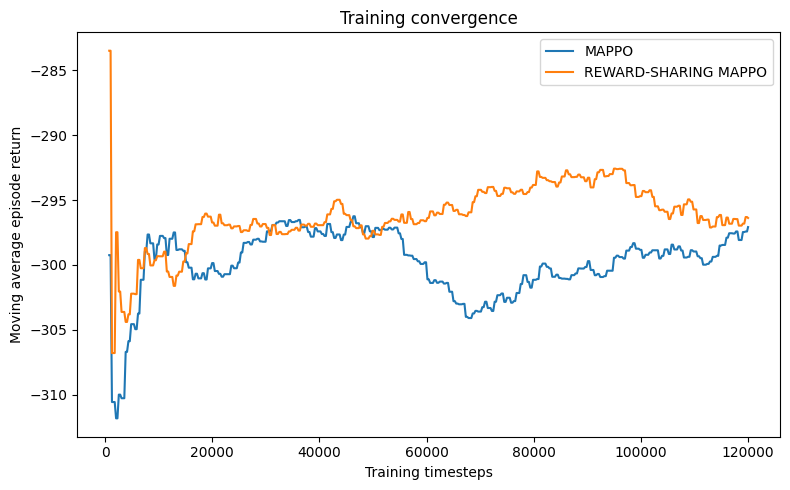

In [7]:
fig, ax = plot_training_histories({
    "MAPPO": mappo_history,
    "Reward-sharing MAPPO": reward_sharing_history,
})
plt.show()

## 3. Export a SUMO replay

In [32]:
replay_config = export_policy_replay(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policy=reward_sharing_model,
    output_dir=OUTPUT_DIR / "replays" / "reward_sharing_mappo",
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
)
print(f"Open this file in the SUMO GUI: {replay_config}")

 Retrying in 1 seconds
 Retrying in 1 seconds
Open this file in the SUMO GUI: /content/marl-tsc/outputs/replays/reward_sharing_mappo/replay.sumocfg


## 4. Compare all policies

Every policy uses the same evaluation episodes, seeds, and environment settings.

In [8]:
policies = {
    "Random": random_actions,
    "Fixed-Time": fixed_time_actions,
    "MAPPO": mappo_model,
    "Reward-sharing MAPPO": reward_sharing_model,
}

policy_results = evaluate_policies(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policies=policies,
    episodes=EVALUATION_EPISODES,
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
)

display(evaluation_results_table(policy_results))

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1202.91
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1310.88
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1335.43
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1028.07
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1026.94
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1022.07
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -706.76
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -669.78
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -693.02
Evaluating Reward-s

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait,Mean time loss,Mean arrivals,Mean switches
0,Random,-1283.075000,0.504635,8.333333,20.895747,244.666667,1708.693571,966.000000,713.666667
1,Fixed-Time,-1025.693750,0.410573,5.000000,15.345032,89.000000,1093.169552,969.333333,396.000000
2,MAPPO,-689.850000,0.260035,4.666667,11.872462,225.000000,764.456590,977.333333,656.000000
3,Reward-sharing MAPPO,-510.235417,0.181962,4.000000,5.676463,190.666667,466.407503,975.666667,732.666667


In [18]:
#!git status
#!git add .
commit = False
if commit:
  import shlex
  commit_msg = '''
  Based on Tom's branch, but with diferrent reward function
  - Uses Throughput Bonus
  - Positive signal for queue improvemt during heavy congestion
  '''
  !git config --global user.email user_email
  !git config --global user.name 'IsaacFayle-Waters'
  !git commit -m {shlex.quote(commit_msg)}

[zak-pre-experiment d0aea23] Based on Tom's branch, but with diferrent reward function - Uses Throughput Bonus - Positive signal for queue improvemt during heavy congestion
 1 file changed, 28 insertions(+)


In [29]:
#!git remote set-url origin https://{token}@github.com/abergh18/marl-tsc.git
#!git push -u origin zak-pre-experiment